# 1. Notebook Setup

In [1]:
import os, random, numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Device:", DEVICE)

Device: cuda


# 2. AMP

In [2]:
if torch.cuda.is_available():
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
    AMP_ENABLED = True
else:
    from contextlib import nullcontext
    autocast = nullcontext
    scaler = None
    AMP_ENABLED = False

/tmp/ipykernel_23/2803221640.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


# 3. Load Dataset

In [3]:
base_path = "/kaggle/input/datasets/saifewu/py-crackdb/Classification"

data = []

for label_name in ["With crack", "Without crack"]:
    class_path = os.path.join(base_path, label_name)
    for img in os.listdir(class_path):
        data.append({
            "image_path": os.path.join(class_path, img),
            "label": 1 if label_name == "With crack" else 0
        })

df = pd.DataFrame(data)

print("Total images:", len(df))

Total images: 569


# 3.1 Train-Test Split

In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# 4. Dataset Class

In [5]:
class BYOLDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image_path"]).convert("RGB")

        x1 = self.transform(img)
        x2 = self.transform(img)

        return x1, x2

# 5. Augmentation

In [6]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4,0.4,0.4,0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(23),
    transforms.ToTensor(),
])

# 6. BYOL Model

In [7]:
class BYOL(nn.Module):
    def __init__(self, projection_dim=256, hidden_dim=512, m=0.996):
        super().__init__()

        self.m = m

        self.encoder = models.resnet18(weights="IMAGENET1K_V1")
        dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.predictor = nn.Sequential(
            nn.Linear(projection_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.target_encoder = models.resnet18(weights="IMAGENET1K_V1")
        self.target_encoder.fc = nn.Identity()

        self.target_projector = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        for param_q, param_k in zip(self.encoder.parameters(), self.target_encoder.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False

    def update_moving_average(self):
        for param_q, param_k in zip(self.encoder.parameters(), self.target_encoder.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)

    def forward(self, x1, x2):
        h1 = self.encoder(x1)
        z1 = self.projector(h1)
        p1 = self.predictor(z1)

        h2 = self.encoder(x2)
        z2 = self.projector(h2)
        p2 = self.predictor(z2)

        with torch.no_grad():
            t1 = self.target_projector(self.target_encoder(x1))
            t2 = self.target_projector(self.target_encoder(x2))

        return p1, p2, t1.detach(), t2.detach()

# 7. BYOL Loss

In [8]:
def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()

# 8. DataLoader

In [9]:
dataset = BYOLDataset(train_df, transform)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

# 9. Training Function

In [10]:
def train(model, loader, epochs=125):
    optimizer = optim.Adam(model.parameters(), lr=3e-4)

    history = []
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x1, x2 in loader:
            x1, x2 = x1.to(DEVICE), x2.to(DEVICE)

            with autocast():
                p1, p2, t1, t2 = model(x1, x2)

                loss = byol_loss(p1, t2) + byol_loss(p2, t1)

            if AMP_ENABLED:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            else:
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            model.update_moving_average()

            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)

        print(f"Epoch {epoch+1}: Loss={avg:.4f}")

    return history

# 10. Train

In [11]:
model = BYOL().to(DEVICE)
loss_history = train(model, loader, epochs=125)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]
/tmp/ipykernel_23/3356130739.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Loss=2.2022
Epoch 2: Loss=1.6753
Epoch 3: Loss=1.6203
Epoch 4: Loss=1.5723
Epoch 5: Loss=1.5400
Epoch 6: Loss=1.4998
Epoch 7: Loss=1.4556
Epoch 8: Loss=1.4131
Epoch 9: Loss=1.3736
Epoch 10: Loss=1.3393
Epoch 11: Loss=1.2738
Epoch 12: Loss=1.2403
Epoch 13: Loss=1.1795
Epoch 14: Loss=1.1303
Epoch 15: Loss=1.0850
Epoch 16: Loss=1.0564
Epoch 17: Loss=1.0161
Epoch 18: Loss=0.9498
Epoch 19: Loss=0.9236
Epoch 20: Loss=0.8738
Epoch 21: Loss=0.8890
Epoch 22: Loss=0.7933
Epoch 23: Loss=0.8189
Epoch 24: Loss=0.7714
Epoch 25: Loss=0.7426
Epoch 26: Loss=0.7195
Epoch 27: Loss=0.7208
Epoch 28: Loss=0.6899
Epoch 29: Loss=0.6673
Epoch 30: Loss=0.6396
Epoch 31: Loss=0.6114
Epoch 32: Loss=0.5826
Epoch 33: Loss=0.6020
Epoch 34: Loss=0.6127
Epoch 35: Loss=0.6069
Epoch 36: Loss=0.5435
Epoch 37: Loss=0.5646
Epoch 38: Loss=0.5502
Epoch 39: Loss=0.5855
Epoch 40: Loss=0.5665
Epoch 41: Loss=0.5422
Epoch 42: Loss=0.5141
Epoch 43: Loss=0.4929
Epoch 44: Loss=0.4974
Epoch 45: Loss=0.5165
Epoch 46: Loss=0.50

# 11. Plot Loss

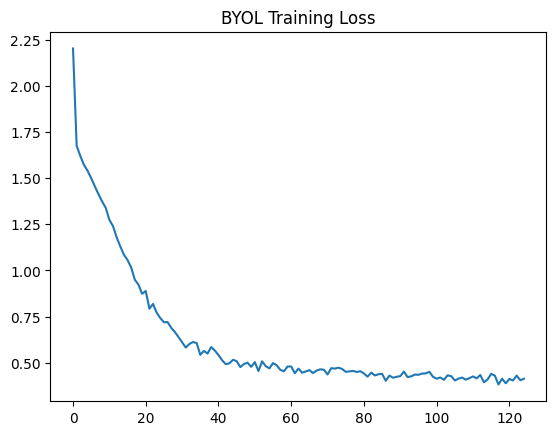

In [12]:
plt.plot(loss_history)
plt.title("BYOL Training Loss")
plt.show()

# 12. Feature Extraction

In [13]:
eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def extract(model, df):
    model.eval()
    feats, labs = [], []

    with torch.no_grad():
        for _, row in df.iterrows():
            img = Image.open(row["image_path"]).convert("RGB")
            img = eval_transform(img).unsqueeze(0).to(DEVICE)

            h = model.encoder(img)
            feats.append(h.cpu().numpy().flatten())
            labs.append(row["label"])

    return np.array(feats), np.array(labs)

train_features, train_labels = extract(model, train_df)
test_features, test_labels = extract(model, test_df)

# 13. Linear Probe

In [14]:
clf = LogisticRegression(max_iter=1000)
clf.fit(train_features, train_labels)

preds = clf.predict(test_features)

print("Accuracy:", accuracy_score(test_labels, preds))
print(classification_report(test_labels, preds))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        74

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



# 14. k-NN

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_features, train_labels)

preds = knn.predict(test_features)
print("kNN Accuracy:", accuracy_score(test_labels, preds))

kNN Accuracy: 1.0


# 15. Label Efficiency

In [16]:
ratios = [0.01,0.05,0.1,0.25,0.5]

for r in ratios:
    X_sub, _, y_sub, _ = train_test_split(
        train_features,
        train_labels,
        train_size=r,
        stratify=train_labels,
        random_state=SEED
    )

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_sub, y_sub)

    acc = clf.score(test_features, test_labels)
    print(f"{int(r*100)}% → {acc:.4f}")

1% → 0.7544
5% → 0.9825
10% → 1.0000
25% → 1.0000
50% → 1.0000


# 16. Save Model

In [17]:
torch.save(model.state_dict(), "byol_encoder.pth")